## 1. Setup and Installation

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import igraph as ig
from scipy.stats import entropy, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")
print(f"igraph version: {ig.__version__}")

✓ All libraries imported successfully
igraph version: 0.11.9


---
## 2. Load Connectivity Data

Loaded connectivity matrix: 72 nodes
Matrix shape: (72, 72)

First few node labels:
  0: DG Granule
  1: DG Semilunar Granule
  2: DG Mossy
  3: DG AIPRIM
  4: DG Axo Axonic


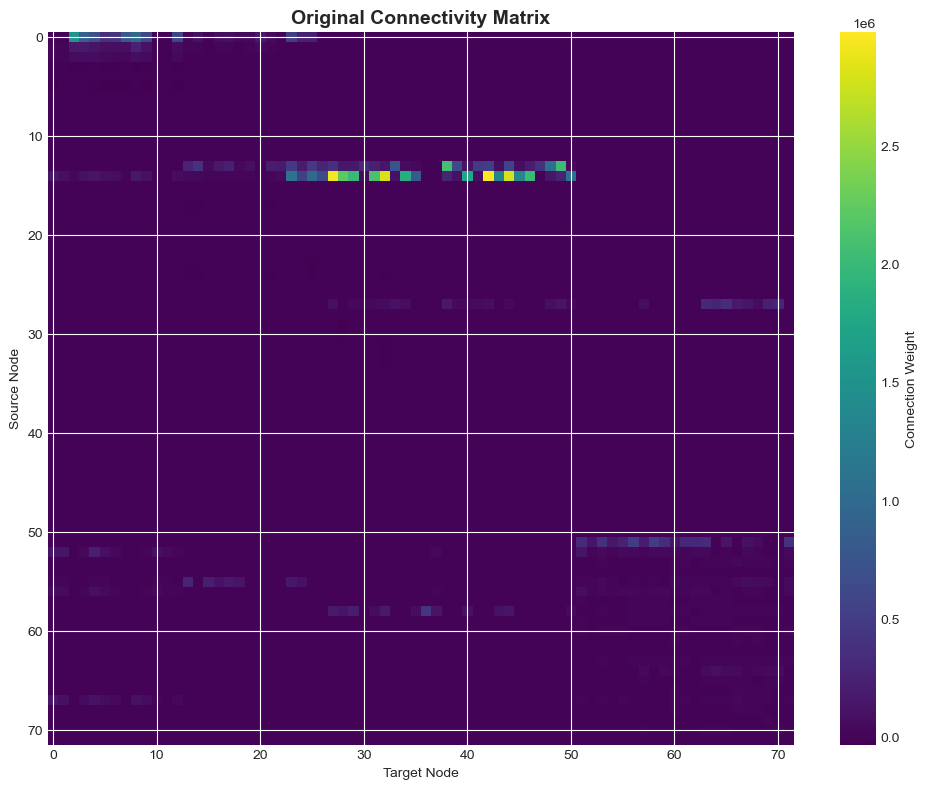

In [2]:
df = pd.read_csv('../data/w_ij_gaa.csv', index_col=0)

W = df.values
node_labels = df.columns.tolist()

print(f"Loaded connectivity matrix: {W.shape[0]} nodes")
print(f"Matrix shape: {W.shape}")
print(f"\nFirst few node labels:")
for i, label in enumerate(node_labels[:5]):
    print(f"  {i}: {label}")

# Display the connectivity matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(W, cmap='viridis', aspect='auto')
ax.set_title('Original Connectivity Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Target Node')
ax.set_ylabel('Source Node')
plt.colorbar(im, ax=ax, label='Connection Weight')
plt.tight_layout()
plt.show()

---
## 3. Build Node-Level Network

First, create a traditional node-level network using igraph.

In [3]:
DIRECTED = True

edges_list = []
edge_weights = []

n_nodes = W.shape[0]

for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j and not np.isnan(W[i,j]) and W[i,j] != 0:
            edges_list.append((i, j))
            edge_weights.append(W[i,j])

# Create node-level igraph network
G_nodes = ig.Graph(directed=DIRECTED)
G_nodes.add_vertices(n_nodes)
G_nodes.vs['name'] = node_labels
G_nodes.add_edges(edges_list)
G_nodes.es['weight'] = edge_weights

print("="*60)
print("NODE-LEVEL NETWORK")
print("="*60)
print(f"Nodes: {G_nodes.vcount()}")
print(f"Edges: {G_nodes.ecount()}")
print(f"Directed: {DIRECTED}")
print(f"Density: {G_nodes.density():.4f}")
print(f"Connected components: {len(G_nodes.components())}")

NODE-LEVEL NETWORK
Nodes: 72
Edges: 1091
Directed: True
Density: 0.2134
Connected components: 1


---
## 4. Build Edge-Level Network (Line Graph Transformation)

Transform the node network into an edge network where:
- Each edge becomes a node
- Two edges are connected if they share a node

In [4]:
edge_nodes = []
edge_labels = []
edge_weights_list = []

for e in G_nodes.es:
    source = e.source
    target = e.target
    edge_nodes.append((source, target))
    
    # Create label
    source_name = G_nodes.vs[source]['name']
    target_name = G_nodes.vs[target]['name']
    arrow = "→" if DIRECTED else "-"
    edge_labels.append(f"{source_name}{arrow}{target_name}")
    
    edge_weights_list.append(e['weight'])

n_edge_nodes = len(edge_nodes)
print(f"Creating edge network with {n_edge_nodes} edge nodes...")

edge_connections = []
connection_types = []

for i in range(n_edge_nodes):
    if i % 100 == 0:
        print(f"  Processing edge {i}/{n_edge_nodes}...", end='\r')
    
    for j in range(i+1, n_edge_nodes):
        edge1 = edge_nodes[i]  # (source1, target1)
        edge2 = edge_nodes[j]  # (source2, target2)
        
        connected = False
        conn_type = ""
        
        if DIRECTED:
            # Check multiple connection types for directed networks
            if edge1[1] == edge2[0]:  # target1 = source2 (sequential)
                connected = True
                conn_type = "sequential"
            elif edge1[0] == edge2[0]:  # same source
                connected = True
                conn_type = "common_source"
            elif edge1[1] == edge2[1]:  # same target
                connected = True
                conn_type = "common_target"
            elif edge1[0] == edge2[1]:  # source1 = target2 (reverse)
                connected = True
                conn_type = "reverse_sequential"
        else:
            # For undirected: edges share a node
            if len(set(edge1) & set(edge2)) > 0:
                connected = True
                conn_type = "shared_node"
        
        if connected:
            edge_connections.append((i, j))
            connection_types.append(conn_type)

print(f"  Found {len(edge_connections)} edge-edge connections")

G_edges = ig.Graph(directed=False)  # Edge functional connectivity (eFC) is a correlation, undirected/symmetrical
G_edges.add_vertices(n_edge_nodes)
G_edges.vs['name'] = edge_labels
G_edges.vs['original_weight'] = edge_weights_list
G_edges.vs['source_node'] = [e[0] for e in edge_nodes]
G_edges.vs['target_node'] = [e[1] for e in edge_nodes]
G_edges.add_edges(edge_connections)
G_edges.es['connection_type'] = connection_types

print("\n" + "="*60)
print("EDGE-LEVEL NETWORK")
print("="*60)
print(f"Edge nodes: {G_edges.vcount()}")
print(f"Edge-edge connections: {G_edges.ecount()}")
print(f"Average degree: {np.mean(G_edges.degree()):.2f}")
print(f"Density: {G_edges.density():.4f}")
print(f"Connected components: {len(G_edges.components())}")

if DIRECTED:
    type_counts = pd.Series(connection_types).value_counts()
    print("\nConnection type distribution:")
    for conn_type, count in type_counts.items():
        print(f"  {conn_type}: {count} ({100*count/len(connection_types):.1f}%)")

Creating edge network with 1091 edge nodes...
  Found 35344 edge-edge connections

EDGE-LEVEL NETWORK
Edge nodes: 1091
Edge-edge connections: 35344
Average degree: 64.79
Density: 0.0594
Connected components: 1

Connection type distribution:
  common_source: 10363 (29.3%)
  common_target: 8924 (25.2%)
  reverse_sequential: 8077 (22.9%)
  sequential: 7980 (22.6%)


---
## 5. Create Edge Functional Connectivity (eFC) Matrix

The eFC matrix is the adjacency matrix of the edge network.

EDGE FUNCTIONAL CONNECTIVITY MATRIX
Shape: (1091, 1091)
Total possible connections: 1190281
Actual connections: 70688
Sparsity: 0.9406


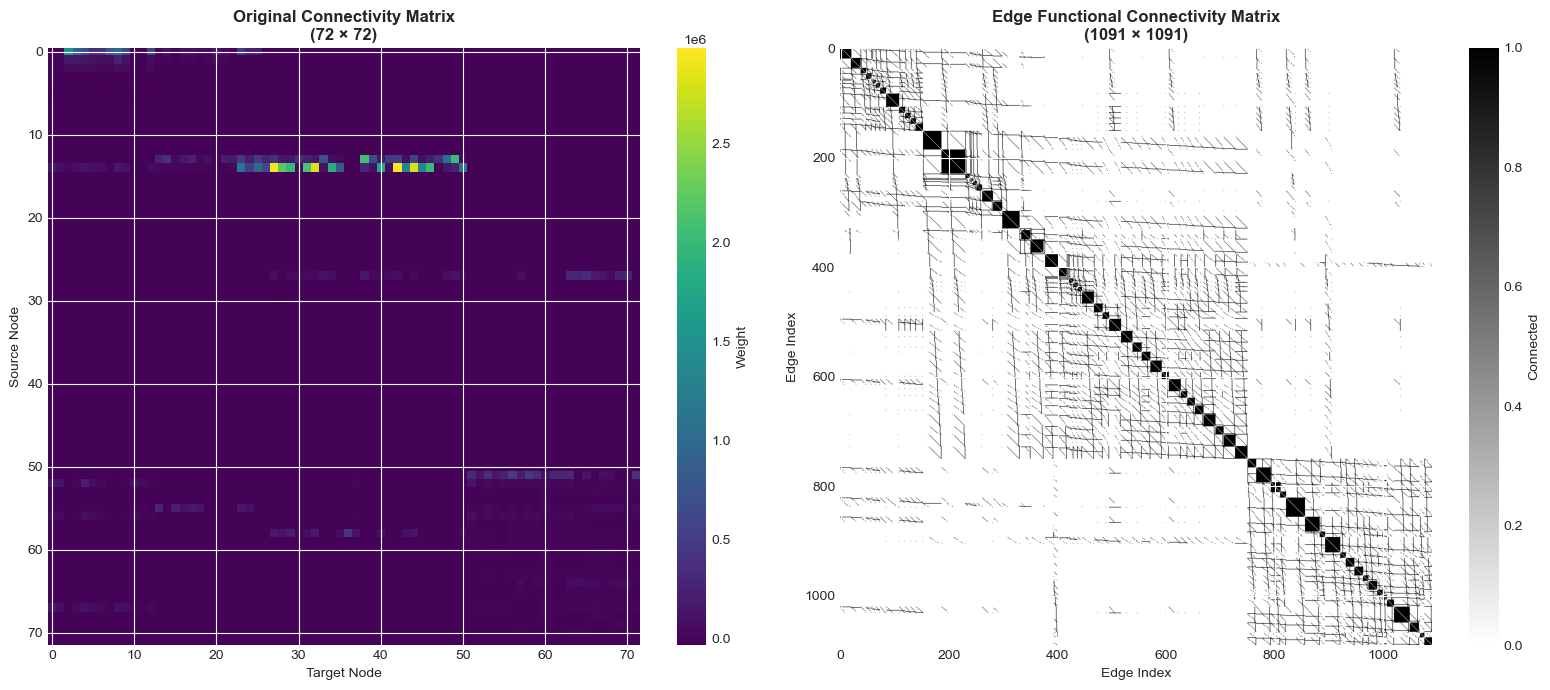

In [5]:
eFC = np.array(G_edges.get_adjacency().data)

print("="*60)
print("EDGE FUNCTIONAL CONNECTIVITY MATRIX")
print("="*60)
print(f"Shape: {eFC.shape}")
print(f"Total possible connections: {eFC.shape[0] * eFC.shape[1]}")
print(f"Actual connections: {np.sum(eFC > 0)}")
print(f"Sparsity: {1 - np.sum(eFC > 0)/(eFC.shape[0] * eFC.shape[1]):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Original connectivity
ax = axes[0]
im = ax.imshow(W, cmap='viridis', aspect='auto')
ax.set_title('Original Connectivity Matrix\n'
             f'({n_nodes} × {n_nodes})', fontsize=12, fontweight='bold')
ax.set_xlabel('Target Node')
ax.set_ylabel('Source Node')
plt.colorbar(im, ax=ax, label='Weight')

# Edge FC matrix
ax = axes[1]
im = ax.imshow(eFC, cmap='binary', aspect='auto')
ax.set_title(f'Edge Functional Connectivity Matrix\n'
             f'({eFC.shape[0]} × {eFC.shape[1]})', fontsize=12, fontweight='bold')
ax.set_xlabel('Edge Index')
ax.set_ylabel('Edge Index')
plt.colorbar(im, ax=ax, label='Connected')

plt.tight_layout()
plt.show()

### ENHANCE!

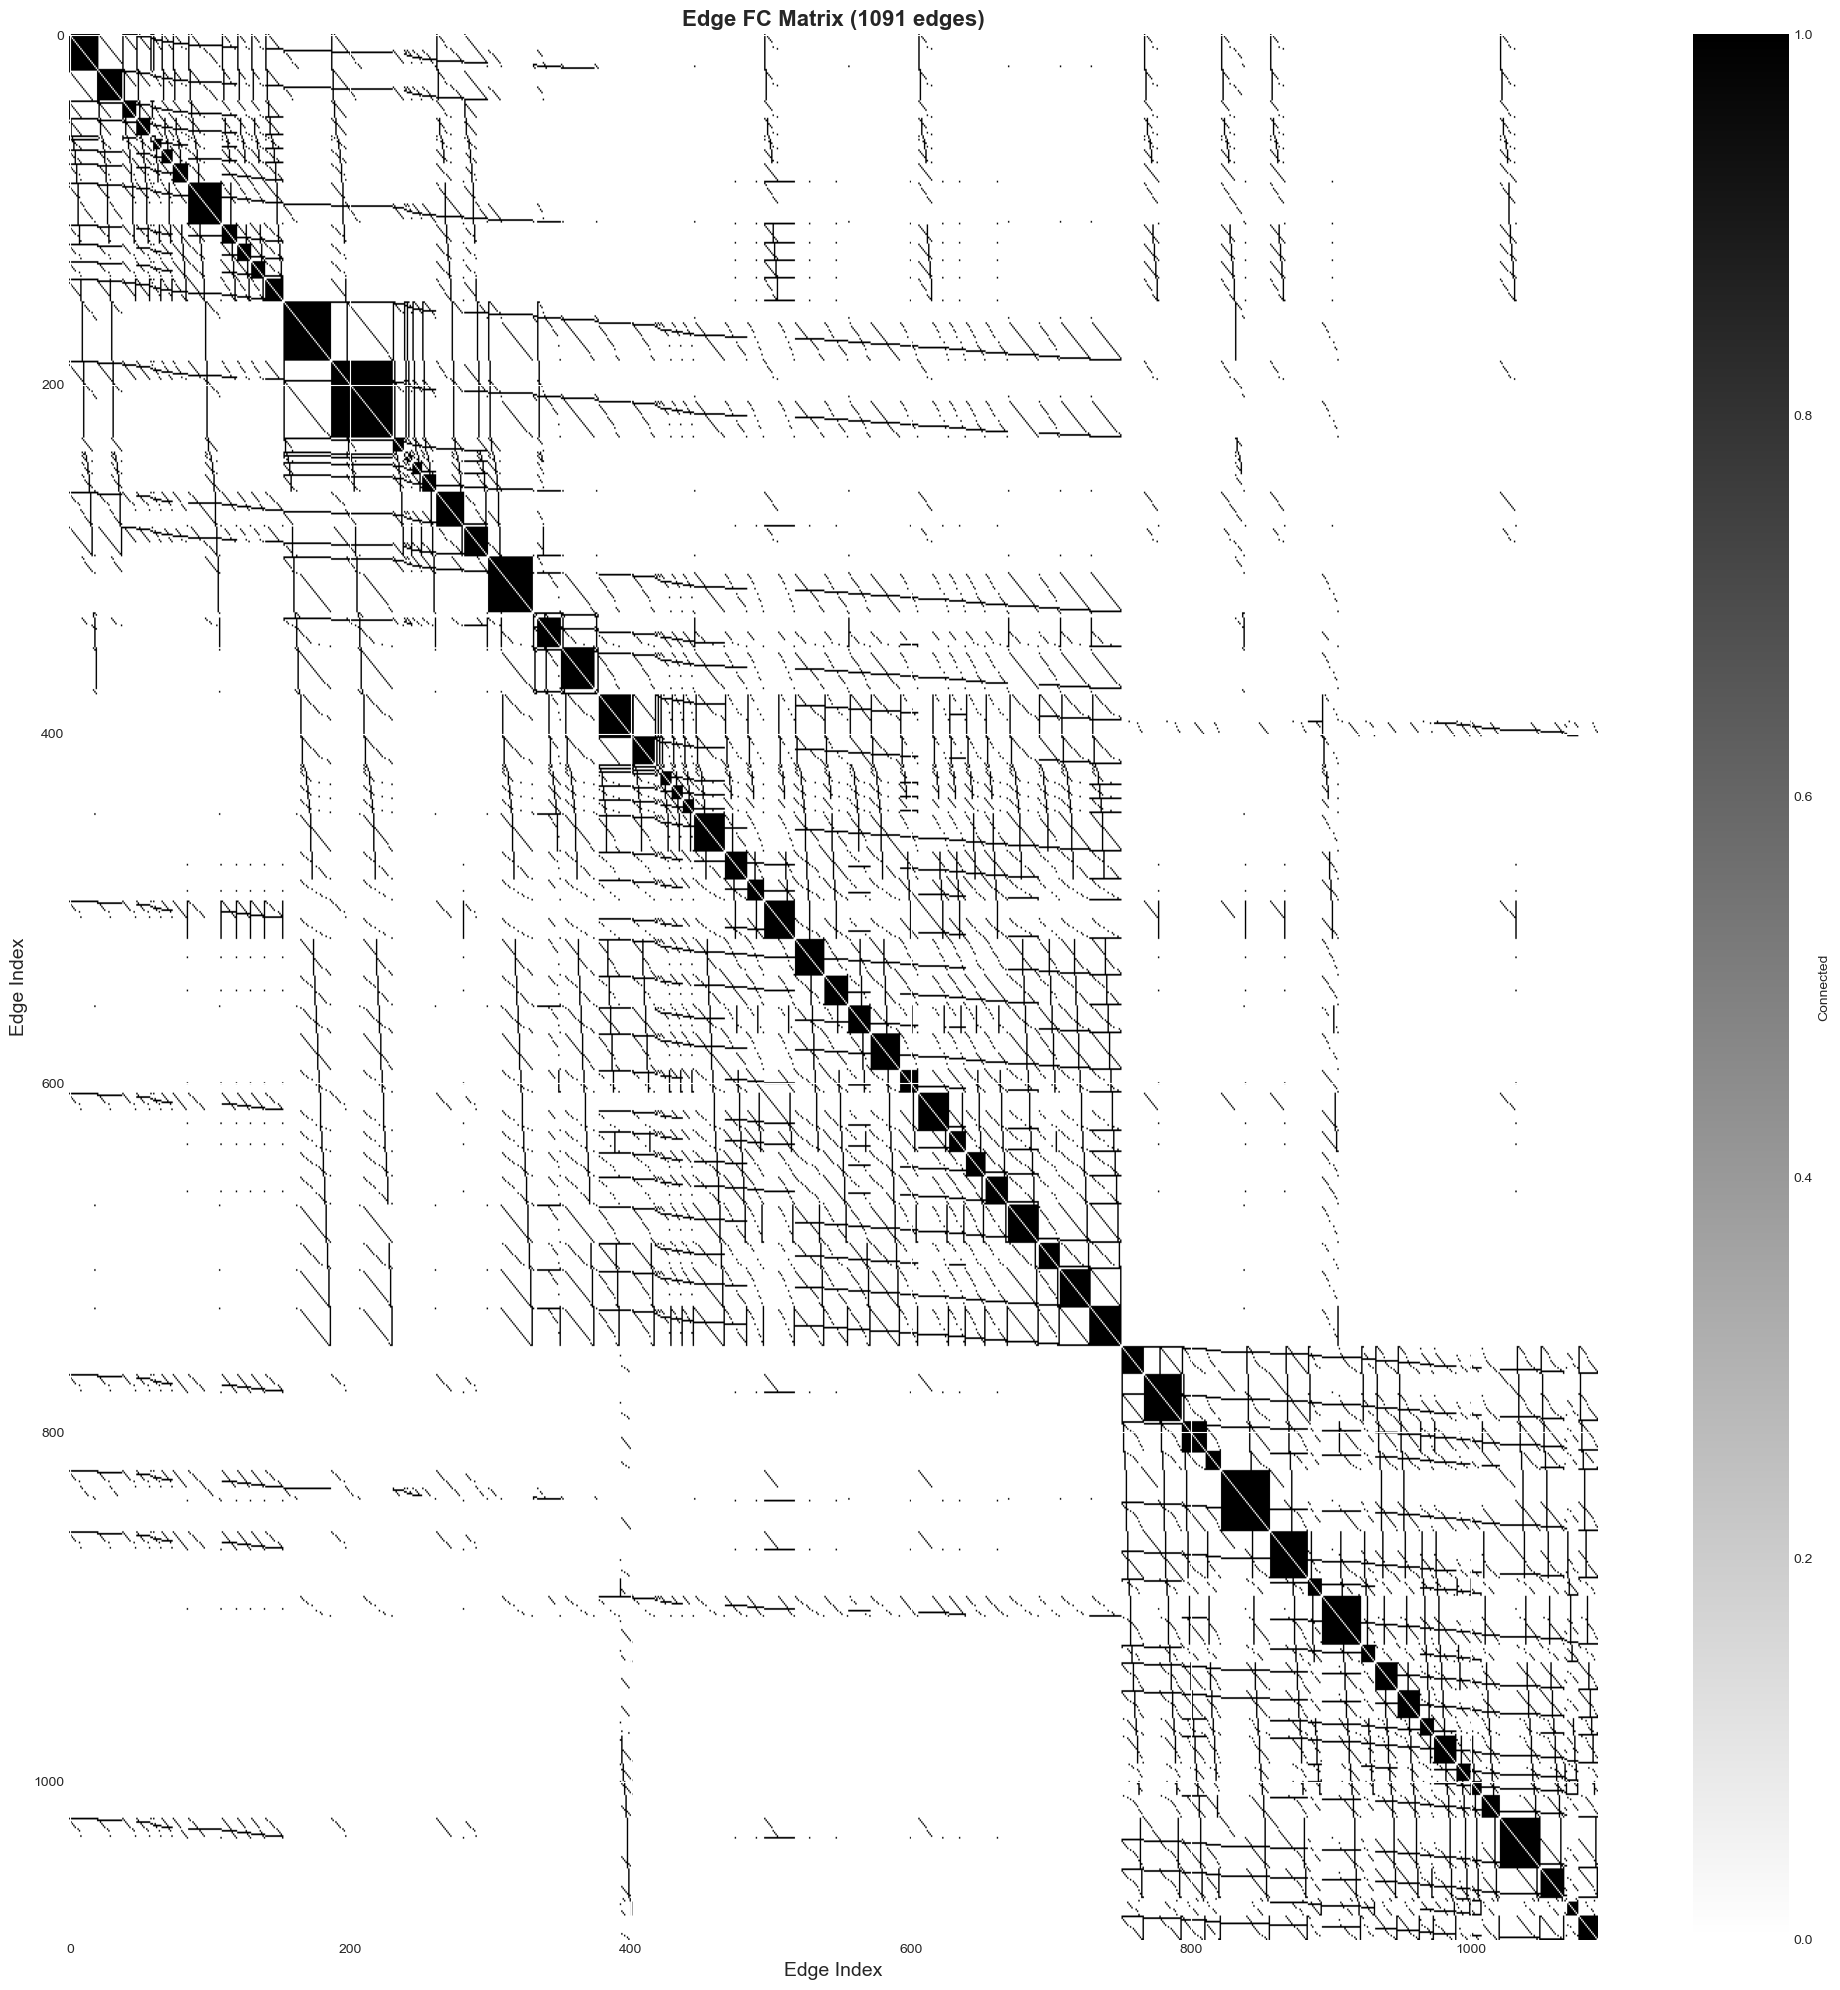

In [13]:
fig, ax = plt.subplots(figsize=(20, 20))  # Huge figure!

im = ax.imshow(eFC, cmap='binary', aspect='auto')
ax.set_title(f'Edge FC Matrix ({eFC.shape[0]} edges)', fontsize=16, fontweight='bold')
ax.set_xlabel('Edge Index', fontsize=14)
ax.set_ylabel('Edge Index', fontsize=14)
plt.colorbar(im, ax=ax, label='Connected')

plt.tight_layout()
plt.savefig('../outputs/edgelist/edge_fc_matrix_LARGE.png', dpi=600, bbox_inches='tight')  # Super high resolution!
plt.show()

---
## 10. Summary Statistics

Create a comprehensive DataFrame with all edge statistics.

In [6]:
# Create comprehensive statistics DataFrame
stats_df = pd.DataFrame({
    'edge_label': edge_labels,
    'source_node': [node_labels[e[0]] for e in edge_nodes],
    'target_node': [node_labels[e[1]] for e in edge_nodes],
    'source_idx': [e[0] for e in edge_nodes],
    'target_idx': [e[1] for e in edge_nodes],
    'original_weight': edge_weights_list
})

print("="*60)
print("EDGE STATISTICS SUMMARY")
print("="*60)
print(f"Total edges analyzed: {len(stats_df)}")
print(f"\nTop 20 edges by betweenness centrality:")
print(stats_df.head(20)[['edge_label']])

# Save to file (optional)
# stats_df.to_csv('edge_statistics.csv', index=False)
# print("\n✓ Statistics saved to 'edge_statistics.csv'")

EDGE STATISTICS SUMMARY
Total edges analyzed: 1091

Top 20 edges by betweenness centrality:
                                     edge_label
0                           DG Granule→DG Mossy
1                          DG Granule→DG AIPRIM
2                      DG Granule→DG Axo Axonic
3                          DG Granule→DG Basket
4                           DG Granule→DG HICAP
5                            DG Granule→DG HIPP
6                          DG Granule→DG HIPROM
7                           DG Granule→DG MOLAX
8           DG Granule→DG Total Molecular Layer
9                      DG Granule→CA3 Pyramidal
10                    DG Granule→CA3c Pyramidal
11                    DG Granule→CA3 Axo Axonic
12                        DG Granule→CA3 Basket
13                 DG Granule→CA3 LMR Targeting
14                  DG Granule→CA3 Lucidum ORAX
15                 DG Granule→CA3 Spiny Lucidum
16  DG Granule→CA3 Mossy Fiber Associated ORDEN
17                        DG Granule→CA2 Bas

In [14]:
# Look up specific edge
edge_200 = stats_df.iloc[200]
print(f"Edge 200: {edge_200['edge_label']}")
print(f"  Source: {edge_200['source_node']}")
print(f"  Target: {edge_200['target_node']}")

# Find edges at a specific position in the matrix
row_idx = 200
col_idx = 350

if eFC[row_idx, col_idx] == 1:
    print(f"\nEdge {row_idx} connects to Edge {col_idx}")
    print(f"  {stats.iloc[row_idx]['edge_label']} ←→ {stats.iloc[col_idx]['edge_label']}")

Edge 200: CA3c Pyramidal→CA3 Axo Axonic
  Source: CA3c Pyramidal
  Target: CA3 Axo Axonic


---
## 12. Export Results

Save all results for further analysis or sharing.

In [12]:
# 1. Save edge statistics
stats_df.to_csv('../outputs/edgelist/edge_statistics.csv', index=False)
print("✓ Saved: edge_statistics.csv")

# 2. Create and save summary figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original connectivity
ax = axes[0]
im = ax.imshow(W, cmap='viridis', aspect='auto')
ax.set_title('Original Connectivity Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Target Node')
ax.set_ylabel('Source Node')
plt.colorbar(im, ax=ax, label='Weight')

# Edge FC matrix
ax = axes[1]
im = ax.imshow(eFC, cmap='binary', aspect='auto')
ax.set_title(f'Edge FC Matrix ({eFC.shape[0]} edges)', fontsize=12, fontweight='bold')
ax.set_xlabel('Edge Index')
ax.set_ylabel('Edge Index')
plt.colorbar(im, ax=ax, label='Connected')

plt.tight_layout()
plt.savefig('../outputs/edgelist/edge_network_summary.png', dpi=300, bbox_inches='tight')
plt.close()  # Close the figure after saving
print("✓ Saved: edge_network_summary.png")

# 3. Save edge FC matrix
np.save('../outputs/edgelist/edge_fc_matrix.npy', eFC)
print("✓ Saved: edge_fc_matrix.npy")

# 4. Export networks for external tools
G_edges.write_graphml('../outputs/edgelist/edge_network.graphml')
print("✓ Saved: edge_network.graphml (for Gephi, Cytoscape, etc.)")

# 5. Save summary report
with open('../outputs/edgelist/analysis_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("EDGE-CENTRIC NETWORK ANALYSIS SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write(f"Node-level network:\n")
    f.write(f"  Nodes: {G_nodes.vcount()}\n")
    f.write(f"  Edges: {G_nodes.ecount()}\n")
    f.write(f"  Directed: {DIRECTED}\n\n")
    f.write(f"Edge-level network:\n")
    f.write(f"  Edge nodes: {G_edges.vcount()}\n")
    f.write(f"  Edge-edge connections: {G_edges.ecount()}\n")
    f.write(f"  Average degree: {np.mean(G_edges.degree()):.2f}\n")
    f.write(f"  Density: {G_edges.density():.4f}\n\n")

print("✓ Saved: analysis_summary.txt")

print("\n" + "="*60)
print("ALL RESULTS EXPORTED SUCCESSFULLY")
print("="*60)

✓ Saved: edge_statistics.csv
✓ Saved: edge_network_summary.png
✓ Saved: edge_fc_matrix.npy
✓ Saved: edge_network.graphml (for Gephi, Cytoscape, etc.)
✓ Saved: analysis_summary.txt

ALL RESULTS EXPORTED SUCCESSFULLY


---
## 13. Final Summary and Next Steps

In [8]:
print("="*60)
print("EDGE-CENTRIC NETWORK ANALYSIS COMPLETE")
print("="*60)
print("\nKey Findings:")
print(f"  • Transformed {G_nodes.vcount()} nodes → {G_edges.vcount()} edge nodes")

print("\nGenerated Files:")
print("  • edge_statistics.csv - Complete edge metrics")
print("  • edge_fc_matrix.npy - Edge connectivity matrix")
print("  • edge_network.graphml - Network file for visualization tools")
print("  • analysis_summary.txt - Text summary")

print("\nNext Steps:")
print("  1. Explore edge_statistics.csv to find interesting patterns")
print("  2. Use node_community_participation.csv for functional analysis")
print("  3. Import edge_network.graphml into Gephi/Cytoscape for interactive viz")
print("  4. Compare edge communities with known functional systems")
print("  5. Investigate hub edges for potential intervention targets")

EDGE-CENTRIC NETWORK ANALYSIS COMPLETE

Key Findings:
  • Transformed 72 nodes → 1091 edge nodes

Generated Files:
  • edge_statistics.csv - Complete edge metrics
  • edge_fc_matrix.npy - Edge connectivity matrix
  • edge_network.graphml - Network file for visualization tools
  • analysis_summary.txt - Text summary

Next Steps:
  1. Explore edge_statistics.csv to find interesting patterns
  2. Use node_community_participation.csv for functional analysis
  3. Import edge_network.graphml into Gephi/Cytoscape for interactive viz
  4. Compare edge communities with known functional systems
  5. Investigate hub edges for potential intervention targets


# DELETE LATER (MAYBE?)

FileNotFoundError: [Errno 2] No such file or directory: 'edge_statistics.csv'